# Notebook 3 — FakeHealth · Gemma-3 Classifier & Benchmark
## Gemma-3 embeddings → Classifieurs ML · Benchmark vs TF-IDF Baselines

**Projet :** A Multi-Source Benchmark for CVD Health Misinformation Detection  
**Dataset :** FakeHealth HealthStory — Dai, Sun & Wang (ICWSM 2020)  
**Modèle :** `google/gemma-3-4b-it` (HuggingFace)  
**Request :** Run two first jupiter notebook NB1 and NB2

--- 

| Aspect | BioBERT | Gemma-3-4B |
|---|---|---|
| Architecture | Encoder (BERT) | Decoder (Causal LM) |
| Embedding token | CLS token (index 0) | **Last non-padding token** |
| Loader | `AutoModel` | `AutoModelForCausalLM` |
| Tokenizer | `AutoTokenizer` | `AutoProcessor` |


In [30]:
# ── Imports
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import glob
import re
import json
import unicodedata
from pathlib import Path

import torch
from transformers import AutoProcessor, AutoModelForCausalLM

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Imports OK')
print(f'   torch   {torch.__version__}')
print(f'   device  {DEVICE}')
print(f'   CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

 Imports OK
   torch   2.10.0+cu128
   device  cpu
   CUDA available: False


# Loading data

In [ ]:
CSV_PATH='../dataset/healthstory_baseline_ready.csv'
df = pd.read_csv(CSV_PATH)
print(f'All data loaded: {len(df)} articles')


All data loaded: 1638 articles


### cleaning data


In [ ]:
# Remove empty texts and reset the DataFrame index to keep embeddings aligned with rows
df = df[df['text'].str.strip().astype(bool)].reset_index(drop=True)
print(f'   Articles conserved : {len(df)} (removed : {n_before - len(df)})')
X = df['text'].values


   Articles conserved : 1604 (removed : 34)


## tu use google/gemma-3-4b-it, you need a token from huggingface and to be logged in with the CLI (huggingface-cli login)

In [ ]:
from huggingface_hub import login
login()

In [ ]:
MODEL_ID = "google/gemma-3-4b-it"

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",
    device_map="auto"
)
model.eval()

print(f' Gemma-3 loaded: {MODEL_ID}')
print(f'   Parameters : {sum(p.numel() for p in model.parameters()):,}')
tokenizer = processor.tokenizer if hasattr(processor, 'tokenizer') else processor

/home/diankham/anaconda3/lib/python3.13/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


 Gemma-3 loaded: google/gemma-3-4b-it
   Parameters : 4,300,079,472


## Section 4 — Gemma-3 Embedding Extraction

**Why last token instead of CLS?**  
Gemma-3 is a causal decoder — there is no CLS token. In decoder models,  
the last token attends to the full sequence and carries the most contextual information.

**Pooling options:**
- `last` — last non-padding token (recommended for causal LMs)
- `mean` — average over all non-padding token vectors

In [ ]:
def extract_gemma_embeddings(
    texts, processor, model, batch_size=1, max_length=512, pooling='last'
):
    """
    Extract fixed-size embeddings from a list of texts using Gemma-3.

    Args:
        texts      : list/array of raw strings to encode.
        processor  : HuggingFace AutoProcessor for Gemma-3.
        model      : HuggingFace AutoModelForCausalLM already loaded.
        batch_size : number of texts per forward pass (1–4 recommended for 4B).
        max_length : maximum number of tokens per text.
        pooling    : 'last' for last non-padding token, 'mean' for mean pooling.

    Returns:
        np.ndarray of shape (n_texts, hidden_size).
    """

    all_embeddings = []
    n = len(texts)

    # Use the tokenizer from the processor
    tok = processor.tokenizer if hasattr(processor, 'tokenizer') else processor

    print(f'Extracting {pooling}-pooled Gemma-3 embeddings ')
    print(f'   {n} texts | batch_size={batch_size} | max_length={max_length}')

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch = list(texts[start:end])

        # Tokenize the current batch
        encoded = tok(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )

       
        input_device = next(model.parameters()).device
        encoded = {k: v.to(input_device) for k, v in encoded.items()}

        with torch.no_grad():
            # output_hidden_states=True is required to get the hidden state matrix
            outputs = model(
                **encoded,
                output_hidden_states=True
            )

        last_hidden = outputs.hidden_states[-1]  

        attention_mask = encoded['attention_mask']  

        if pooling == 'last':
            # Index of the last non-padding token per sequence
            # attention_mask: 1 = real token, 0 = padding
            seq_lengths = attention_mask.sum(dim=1) - 1  # (batch,)
            batch_idx = torch.arange(last_hidden.size(0), device=last_hidden.device)
            embeddings = last_hidden[batch_idx, seq_lengths, :] 
            
        elif pooling == 'mean':
            # Mean over non-padding tokens
            mask = attention_mask.unsqueeze(-1).float()  # (batch, seq_len, 1)
            embeddings = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1)  # (batch, hidden_size)

        else:
            raise ValueError(f'Unknown pooling: {pooling}. Choose "last" or "mean".')

        all_embeddings.append(embeddings.cpu().float().numpy())

        if (start // batch_size) % 10 == 0:
            print(f'   [{end}/{n}] done', end='\r')

    print(f'   [{n}/{n}] done        ')

    result = np.vstack(all_embeddings)
    print(f' Embedding matrix shape: {result.shape}')
    return result

In [ ]:
# Embedding cache — avoid re-extracting every time
EMBEDDING_CACHE_PATH = 'gemma3_embeddings.npy'

if os.path.exists(EMBEDDING_CACHE_PATH):
    print(f'Loading cached embeddings from {EMBEDDING_CACHE_PATH} ...')
    X_embeddings = np.load(EMBEDDING_CACHE_PATH)
    print(f' Embeddings loaded: {X_embeddings.shape}')
else:
    print('No cached embeddings found, extracting from Gemma-3 — this may take a while... (30 mins expected)')
    X_embeddings = extract_gemma_embeddings(
        texts=X,
        processor=processor,
        model=model,
        batch_size=1,       
        max_length=512,
        pooling='last'     
    )
    np.save(EMBEDDING_CACHE_PATH, X_embeddings)
    print(f'Embeddings saved to cache: {EMBEDDING_CACHE_PATH}')

print('All steps completed successfully.')

Loading cached embeddings from gemma3_embeddings.npy ...
 Embeddings loaded: (1604, 2560)
All steps completed successfully.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Cardiovascular / diabetes query terms (same as NB3 BioBERT)
queries = [
    "cardiovascular disease", "cardiovascular disorders", "heart disease", "cardiac disease",
    "coronary artery disease", "coronary heart disease", "ischemic heart disease",
    "myocardial ischemia", "myocardial infarction", "heart attack", "acute coronary syndrome",
    "stroke", "ischemic stroke", "hemorrhagic stroke", "cerebrovascular accident",
    "transient ischemic attack", "tia", "hypertension", "high blood pressure",
    "arterial hypertension", "heart failure", "congestive heart failure",
    "arrhythmia", "atrial fibrillation", "ventricular arrhythmia",
    "chest pain", "angina", "stable angina", "unstable angina",
    "shortness of breath", "dyspnea", "exertional dyspnea", "palpitations",
    "tachycardia", "bradycardia", "fatigue", "chronic fatigue",
    "exercise intolerance", "dizziness", "vertigo", "lightheadedness",
    "syncope", "fainting", "loss of consciousness", "edema", "peripheral edema", "swelling",
    "smoking", "tobacco use", "nicotine exposure", "obesity", "overweight", "bmi",
    "body mass index", "high cholesterol", "hyperlipidemia", "ldl", "hdl", "triglycerides",
    "diabetes", "insulin resistance", "sedentary lifestyle", "physical inactivity",
    "family history", "genetic predisposition", "age", "male sex", "stress", "poor diet",
    "statins", "beta-blockers", "ace inhibitors", "arbs", "antihypertensive drugs",
    "anticoagulants", "blood thinners", "aspirin therapy", "antiplatelet therapy",
    "angioplasty", "percutaneous coronary intervention", "stent", "coronary stent",
    "bypass surgery", "coronary artery bypass graft", "cardiac rehabilitation",
    "ecg", "electrocardiogram", "ekg", "blood pressure", "ambulatory blood pressure monitoring",
    "cholesterol levels", "lipid panel", "troponin", "cardiac biomarkers",
    "echocardiogram", "cardiac ultrasound", "stress test", "exercise tolerance test",
    "ct angiography",
    "type 1 diabetes", "type 2 diabetes", "gestational diabetes", "prediabetes",
    "latent autoimmune diabetes", "lada", "mody", "maturity onset diabetes of the young",
    "frequent urination", "polyuria", "excessive thirst", "polydipsia", "polyphagia",
    "increased appetite", "weight loss", "unexplained weight loss", "blurred vision",
    "slow wound healing", "fatigue", "lethargy",
    "insulin", "insulin therapy", "metformin", "oral hypoglycemics", "glucose-lowering drugs",
    "sulfonylureas", "glp-1 agonists", "sglt2 inhibitors", "lifestyle intervention",
    "diet control", "carbohydrate counting", "continuous glucose monitoring", "cgm",
    "blood glucose", "blood sugar", "fasting glucose", "postprandial glucose",
    "hba1c", "glycated hemoglobin", "insulin level", "glucose tolerance test", "ogtt", "c-peptide",
    "neuropathy", "diabetic neuropathy", "nephropathy", "kidney disease",
    "retinopathy", "diabetic retinopathy", "diabetic foot ulcer",
    "cardiovascular complications", "macrovascular complications", "microvascular complications"
]


def embed_queries_gemma(queries, processor, model, max_length=128):
    """Embed short query strings using Gemma-3 (last-token pooling)."""
    model.eval()
    tok = processor.tokenizer if hasattr(processor, 'tokenizer') else processor
    enc = tok(
        queries,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )
    input_device = next(model.parameters()).device
    enc = {k: v.to(input_device) for k, v in enc.items()}
    with torch.no_grad():
        outputs = model(**enc, output_hidden_states=True)
    last_hidden = outputs.hidden_states[-1]
    seq_lengths = enc['attention_mask'].sum(dim=1) - 1
    batch_idx = torch.arange(last_hidden.size(0), device=last_hidden.device)
    embeddings = last_hidden[batch_idx, seq_lengths, :]
    return embeddings.cpu().float().numpy()


q_emb = embed_queries_gemma(queries, processor, model)
df['topic_score'] = cosine_similarity(X_embeddings, q_emb).max(axis=1)

SEUIL_STRICT = 0.25   # adjust if needed. If >= 0.5, no rows selected
selected_df = (
    df[df['topic_score'] >= SEUIL_STRICT]
    .sort_values('topic_score', ascending=False)
    .copy()
)

print(f'Selected {len(selected_df)} rows')
selected_df.head(10)

Selected 1533 rows


,file_id,title,text,label,label_name,rating_float,dataset,topic_score
988,story_reviews_00098,How barbershops could help lower blood pressure,How barbershops could help lower blood pressure,1,Real,5,HealthStory,0.676903
450,story_reviews_00922,Patient's own stem cells help heal heart,Patient's own stem cells help heal heart,1,Real,4,HealthStory,0.672197
1558,story_reviews_01357,Viagra may help heart effects of muscular dyst...,Viagra may help heart effects of muscular dyst...,0,Fake,2,HealthStory,0.631782
1592,story_reviews_01008,Yoga shows some benefit for diabetes,Yoga shows some benefit for diabetes,0,Fake,2,HealthStory,0.624395
1372,story_reviews_01239,Antidepressants relieve hot flashes,Antidepressants relieve hot flashes,0,Fake,2,HealthStory,0.621835
1363,story_reviews_00848,Botox may help multiple sclerosis tremors,Botox may help multiple sclerosis tremors,1,Real,5,HealthStory,0.610289
64,story_reviews_01193,"More unusual, fewer usual breaks with bone drugs","More unusual, fewer usual breaks with bone drugs",1,Real,5,HealthStory,0.599967
782,story_reviews_00700,Curcumin may help lower inflammation in metabo...,Curcumin may help lower inflammation in metabo...,1,Real,3,HealthStory,0.598831
864,story_reviews_01686,Using CT scans to see plaque in coronary arteries,Using CT scans to see plaque in coronary arteries,1,Real,3,HealthStory,0.598184
512,story_reviews_01015,"Bran, soy help cut cholesterol","Bran, soy help cut cholesterol",0,Fake,2,HealthStory,0.592781


## Section 5 : Train / Split
80/20 stratified split.  
`random_state=42`.

In [23]:
X_selected = X_embeddings[selected_df.index]
y_selected = selected_df['label'].values

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_selected,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_selected
)
print(' Split Train and Test')
print(f'  Train : {len(X_train)} articles  |  Fake: {(y_train==0).sum()}  Real: {(y_train==1).sum()}')
print(f'  Test  : {len(X_test)}  articles  |  Fake: {(y_test==0).sum()}  Real: {(y_test==1).sum()}')

 Split Train and Test
  Train : 1226 articles  |  Fake: 346  Real: 880
  Test  : 307  articles  |  Fake: 87  Real: 220


Gemma-3 embeddings are high-dimensional dense vectors.  
We test three classifiers:

| Classifier | Notes |
|---|---|
| Logistic Regression | L2 regularization, `balanced` class weight |
| LinearSVC | Fast linear classifier, `balanced` class weight |
| MLP (2-layer) | Non-linear, can capture interactions in embedding space |

In [25]:
# ── Classifiers on top of Gemma-3 embeddings

clf_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15
    ))
])

gemma_models = {
    'Gemma3 + LR':        clf_lr,
    'Gemma3 + LinearSVC': clf_svm,
    'Gemma3 + MLP':       clf_mlp,
}

for name in gemma_models:
    print(f'   • {name}')

   • Gemma3 + LR
   • Gemma3 + LinearSVC
   • Gemma3 + MLP


In [26]:
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results_g4 = {}

for name, clf in gemma_models.items():
    cv = cross_validate(
        clf, X_embeddings, y,
        cv=SKF,
        scoring={
            'accuracy'        : 'accuracy',
            'f1_macro'        : 'f1_macro',
            'precision_macro' : 'precision_macro',
            'recall_macro'    : 'recall_macro',
        },
        return_train_score=False,
        n_jobs=-1
    )
    cv_results_g4[name] = cv

    print(f'── {name} ──')
    print(f'  Accuracy  : {cv["test_accuracy"].mean():.4f} ± {cv["test_accuracy"].std():.4f}')
    print(f'  F1 macro  : {cv["test_f1_macro"].mean():.4f} ± {cv["test_f1_macro"].std():.4f}')
    print(f'  Precision : {cv["test_precision_macro"].mean():.4f} ± {cv["test_precision_macro"].std():.4f}')
    print(f'  Recall    : {cv["test_recall_macro"].mean():.4f} ± {cv["test_recall_macro"].std():.4f}')
    print()

── Gemma3 + LR ──
  Accuracy  : 0.5929 ± 0.0151
  F1 macro  : 0.5102 ± 0.0153
  Precision : 0.5109 ± 0.0154
  Recall    : 0.5117 ± 0.0169



/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


── Gemma3 + LinearSVC ──
  Accuracy  : 0.5941 ± 0.0070
  F1 macro  : 0.5190 ± 0.0098
  Precision : 0.5195 ± 0.0099
  Recall    : 0.5214 ± 0.0111

── Gemma3 + MLP ──
  Accuracy  : 0.6627 ± 0.0173
  F1 macro  : 0.5043 ± 0.0335
  Precision : 0.5190 ± 0.0372
  Recall    : 0.5155 ± 0.0227



In [27]:
test_results_g4 = {}

for name, clf in gemma_models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    test_results_g4[name] = {
        'y_pred'    : y_pred,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'prec_macro': precision_score(y_test, y_pred, average='macro'),
        'rec_macro' : recall_score(y_test, y_pred, average='macro'),
        'f1_macro'  : f1_score(y_test, y_pred, average='macro'),
        'f1_fake'   : f1_score(y_test, y_pred, pos_label=0),
        'f1_real'   : f1_score(y_test, y_pred, pos_label=1),
    }

    print(f'── {name} — Test Set ──')
    print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

── Gemma3 + LR — Test Set ──
              precision    recall  f1-score   support

        Fake       0.30      0.34      0.32        87
        Real       0.73      0.69      0.71       220

    accuracy                           0.59       307
   macro avg       0.51      0.52      0.51       307
weighted avg       0.61      0.59      0.60       307



/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


── Gemma3 + LinearSVC — Test Set ──
              precision    recall  f1-score   support

        Fake       0.30      0.32      0.31        87
        Real       0.72      0.70      0.71       220

    accuracy                           0.59       307
   macro avg       0.51      0.51      0.51       307
weighted avg       0.60      0.59      0.60       307

── Gemma3 + MLP — Test Set ──
              precision    recall  f1-score   support

        Fake       0.34      0.16      0.22        87
        Real       0.73      0.88      0.79       220

    accuracy                           0.67       307
   macro avg       0.53      0.52      0.51       307
weighted avg       0.62      0.67      0.63       307



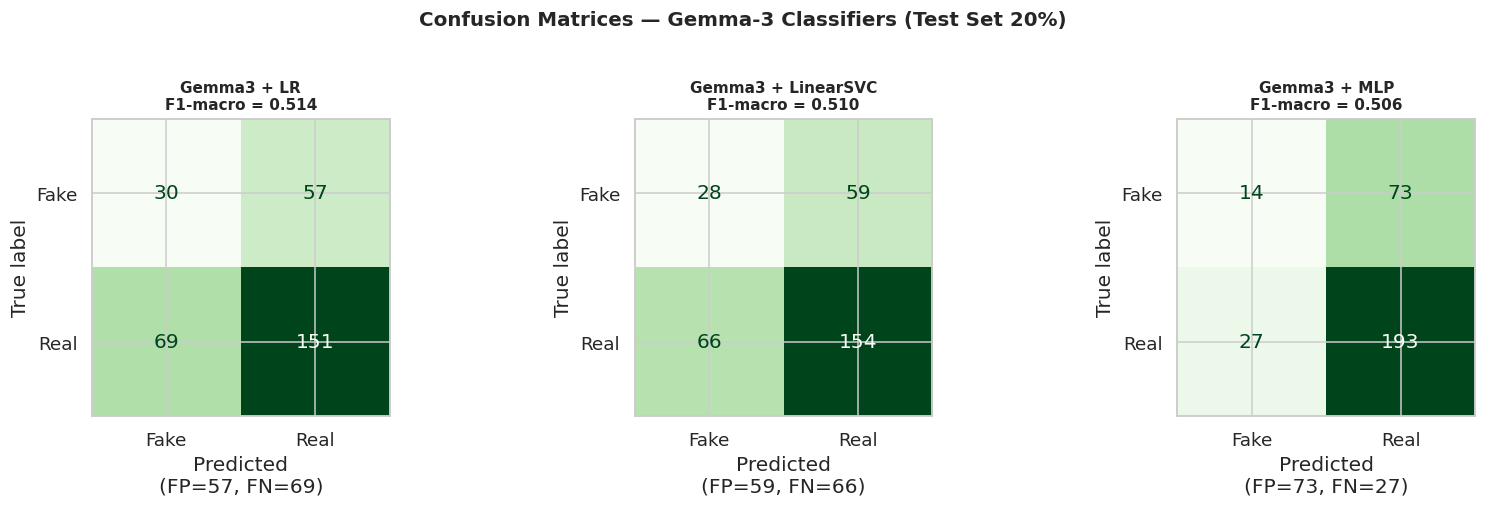

In [28]:
n_models = len(gemma_models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, test_results_g4.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Fake', 'Real'])
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f'{name}\nF1-macro = {res["f1_macro"]:.3f}',
                 fontsize=10, fontweight='bold')
    fn = cm[1][0]
    fp = cm[0][1]
    ax.set_xlabel(f'Predicted\n(FP={fp}, FN={fn})')

plt.suptitle('Confusion Matrices — Gemma-3 Classifiers (Test Set 20%)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_gemma3_confusion_matrices.png', bbox_inches='tight', dpi=130)
plt.show()

In [29]:
print('=' * 100)

header = f'{"Modèle":<30} {"Acc":>7} {"Prec":>7} {"Recall":>7} {"F1-mac":>7} {"F1-Fake":>8} {"F1-Real":>8} {"CV F1±σ":>13}'
print(header)
print('-' * 100)

for name, res in test_results_g4.items():
    cv = cv_results_g4.get(name)
    if cv is not None and 'test_f1_macro' in cv:
        cv_f1_mean = cv['test_f1_macro'].mean()
        cv_f1_std  = cv['test_f1_macro'].std()
    else:
        cv_f1_mean = float('nan')
        cv_f1_std  = float('nan')

    row = (
        f'{name:<30} '
        f'{res["accuracy"]:>7.3f} '
        f'{res["prec_macro"]:>7.3f} '
        f'{res["rec_macro"]:>7.3f} '
        f'{res["f1_macro"]:>7.3f} '
        f'{res["f1_fake"]:>8.3f} '
        f'{res["f1_real"]:>8.3f} '
        f'{cv_f1_mean:>6.3f}±{cv_f1_std:.3f}'
    )
    print(row)

print('=' * 100)

Modèle                             Acc    Prec  Recall  F1-mac  F1-Fake  F1-Real       CV F1±σ
----------------------------------------------------------------------------------------------------
Gemma3 + LR                      0.590   0.514   0.516   0.514    0.323    0.706  0.510±0.015
Gemma3 + LinearSVC               0.593   0.510   0.511   0.510    0.309    0.711  0.519±0.010
Gemma3 + MLP                     0.674   0.534   0.519   0.506    0.219    0.794  0.504±0.034
